In [1]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import glob
import os
import sklearn.cluster as clust
import sklearn.mixture as mix
import statistics
import scipy.stats 

In [2]:
arka12_binding_surface_no_salt = pd.read_csv('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/pair_wise_distances/csv/combined/wild_binding_pairwise.csv')
arka12_binding_surface_salt = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/csv/combined/salt_binding_distances.csv')

In [3]:
arka12_dihed_no_salt = pd.read_table('/home/jqali/data/salt_project/analysis/RMSD/dihedrals_all_no_salt.dat', sep = r'\s+')
arka12_dihed_salt = pd.read_table('/data/mcohen3/SH3/analysis/dihedral/dat/dihedral.dat', sep = r'\s+')

In [4]:
PDB = pd.read_csv('/data/ch343/ArkA12/analysis_tot/old_files/dihedrals_pdb.dat', sep = r'\s+')
#endtoend = pd.read_csv('endtoend.dat', '\s+')
dihedrals_summary = PDB.copy()
del PDB['#Frame']
#del PDB['psi:13']
#del bound_dihed['#Frame']
del arka12_dihed_no_salt['#Frame']
del arka12_dihed_salt['#Frame']
#del seg1_dihed['#Frame']
#del REMD_dihed['#Frame']
#del REMD_dihed['Unnamed: 0']
#del REMD_dihed['psi:13']
#del arka12_dihed['#Frame']
#del arka12_dihed['psi:71']
#del arka12_dihed_17['#Frame.1']
#del arka12_dihed_17['#Frame']
#del arka12_dihed_17['Unnamed: 0']

In [5]:
dihedrals_dif_no_salt = (arka12_dihed_no_salt - PDB.values.squeeze())
dihedrals_dif_no_salt[dihedrals_dif_no_salt>180] = 360 - dihedrals_dif_no_salt
dihedrals_dif_no_salt[dihedrals_dif_no_salt<-180] = 360 + dihedrals_dif_no_salt        
dihedrals_dif_sqr_no_salt_binding = dihedrals_dif_no_salt**2
dihedrals_dif_sqr_no_salt_binding['RMSD'] = np.sqrt(dihedrals_dif_sqr_no_salt_binding.sum(axis=1)/34)

Current dimensions: 8.0 x 6.0 inches
New dimensions: 5 x 3.75 inches


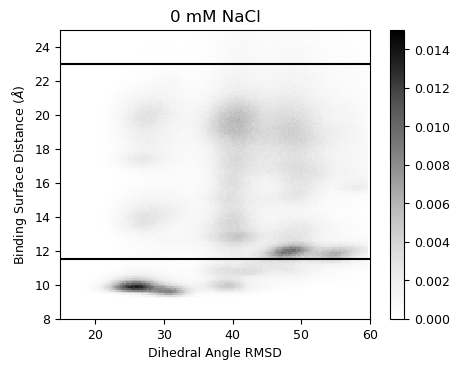

In [10]:
x = dihedrals_dif_sqr_no_salt_binding['RMSD']
y = arka12_binding_surface_no_salt['avg']
fig = plt.figure(figsize=(8,6))

binedges_x = np.arange(0,60,0.3)
binedges_y = np.arange(0,30,0.1)
#test_x, test_y = np.meshgrid(binedges_x,binedges_y)
test= plt.hist2d(x, y, bins=[binedges_x,binedges_y], density= True, cmap = 'Greys')

#max_shade = test[0].max()
#ax = fig.add_subplot(111)
plt.ylim(8,25)
plt.xlim(15,60)
plt.clim(0,0.015)
plt.title('0 mM NaCl', fontsize=12)
plt.xlabel('Dihedral Angle RMSD', fontsize = 9)
plt.ylabel('Binding Surface Distance ($\AA$)',fontsize = 9)
plt.plot([0,97500],[11.5,11.5], 'k-') # plot a horizontal line that indictes the cut off mark for the bound stage
plt.plot([0,97500],[23,23], 'k-') # plot a horizontal line that indictes the cut off mark for the encounter complex
cbar = plt.colorbar()
#plt.savefig('cisp2_binding_surfacebound_surface_drmsd_hist.pdf', dpi=1000)
plt.xticks(size=9)
plt.yticks(size=9)

cbar.ax.tick_params(labelsize=9)
# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.show()

In [8]:
dihedrals_dif_salt = (arka12_dihed_salt - PDB.values.squeeze())
dihedrals_dif_salt[dihedrals_dif_salt>180] = 360 - dihedrals_dif_salt
dihedrals_dif_salt[dihedrals_dif_salt<-180] = 360 + dihedrals_dif_salt        
dihedrals_dif_sqr_salt_binding = dihedrals_dif_salt**2
dihedrals_dif_sqr_salt_binding['RMSD'] = np.sqrt(dihedrals_dif_sqr_salt_binding.sum(axis=1)/34)

Current dimensions: 8.0 x 6.0 inches
New dimensions: 5 x 3.75 inches


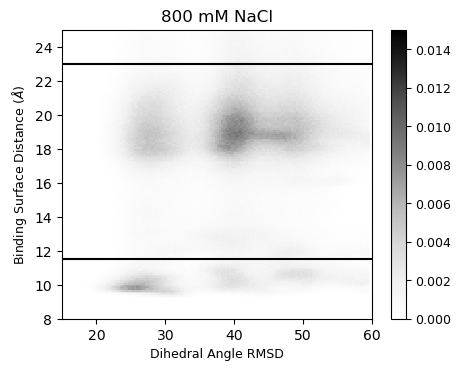

In [9]:
x = dihedrals_dif_sqr_salt_binding['RMSD']
y = arka12_binding_surface_salt['avg']
fig = plt.figure(figsize=(8,6))

binedges_x = np.arange(0,60,0.3)
binedges_y = np.arange(0,30,0.1)
#test_x, test_y = np.meshgrid(binedges_x,binedges_y)
test= plt.hist2d(x, y, bins=[binedges_x,binedges_y], density= True, cmap = 'Greys')

#max_shade = test[0].max()
#ax = fig.add_subplot(111)
plt.ylim(8,25)
plt.xlim(15,60)
plt.clim(0,0.015)
plt.title('800 mM NaCl', fontsize=12)
plt.xlabel('Dihedral Angle RMSD', fontsize = 9)
plt.ylabel('Binding Surface Distance ($\AA$)',fontsize = 9)
plt.plot([0,97500],[11.5,11.5], 'k-') # plot a horizontal line that indictes the cut off mark for the bound stage
plt.plot([0,97500],[23,23], 'k-') # plot a horizontal line that indictes the cut off mark for the encounter complex
cbar = plt.colorbar()
#plt.savefig('cisp2_binding_surfacebound_surface_drmsd_hist.pdf', dpi=1000)
cbar.ax.tick_params(labelsize=9)
# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.show()